# 🏦 Loan Approval Prediction System

### Machine Learning Classification Project

**Objective:** Predict whether a loan application should be approved based on applicant information.

---

# 📌 Phase 1: Data Loading & Understanding

In this phase, we will:

- Import required libraries
- Upload and load the dataset
- Inspect the dataset
- Check missing values
- Check duplicates
- Explore basic statistics
- Understand the target variable

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

print("Libraries Imported Successfully!")

# Upload Dataset
from google.colab import files

print("\nUpload train.csv")
uploaded = files.upload()



Libraries Imported Successfully!

Upload train.csv


Saving train_u6lujuX_CVtuZ9i.csv to train_u6lujuX_CVtuZ9i.csv


In [4]:
# Load Dataset
df = pd.read_csv("train.csv")

print("\nDataset Loaded Successfully!")

# Shape
print("\nDataset Shape :", df.shape)

# First Five Rows
print("\nFirst Five Rows")
display(df.head())

# Dataset Information
print("\nDataset Information")
df.info()

# Statistical Summary
print("\nStatistical Summary")
display(df.describe())

# Missing Values
print("\nMissing Values")
display(df.isnull().sum())

# Duplicate Rows
print("\nDuplicate Rows :", df.duplicated().sum())

# Data Types
print("\nData Types")
display(df.dtypes)

# Target Variable Distribution
print("\nLoan Status Distribution")
display(df["Loan_Status"].value_counts())

print("\nLoan Status Percentage")
display((df["Loan_Status"].value_counts(normalize=True)*100).round(2))



Dataset Loaded Successfully!

Dataset Shape : (614, 13)

First Five Rows


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB

Statistical Summary


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000



Missing Values


...

,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64



Loan Status Distribution


,count
Loan_Status,
Y,422
N,192



Loan Status Percentage


,proportion
Loan_Status,
Y,68.73
N,31.27


# 📊 Phase 2: Exploratory Data Analysis (EDA)

In this phase, we will explore the dataset using visualizations to identify patterns, trends, class distributions, and potential issues before preprocessing.

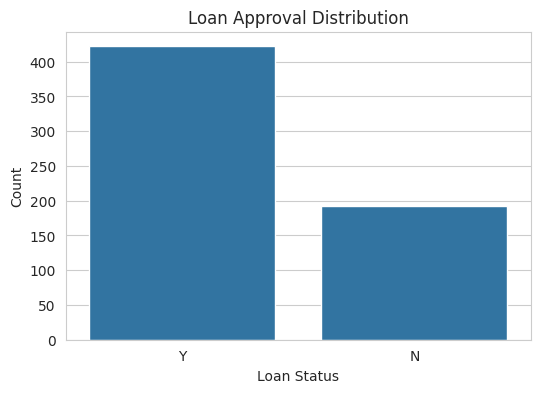

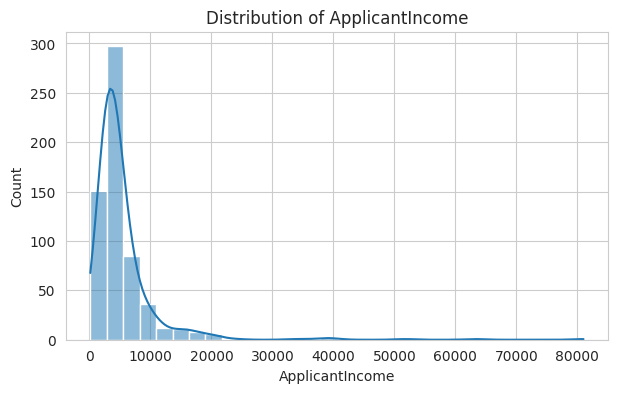

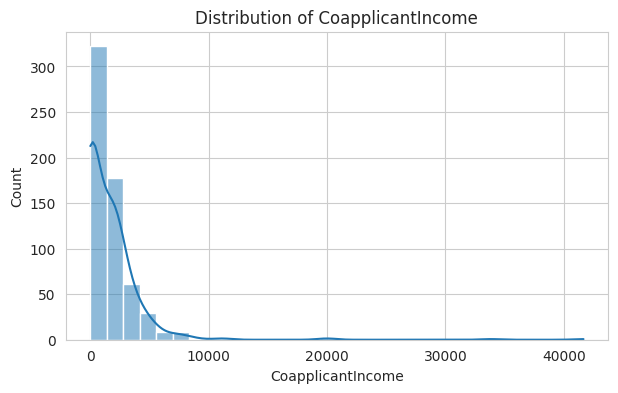

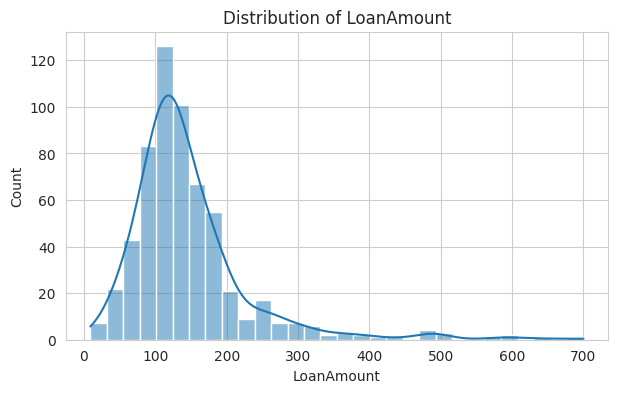

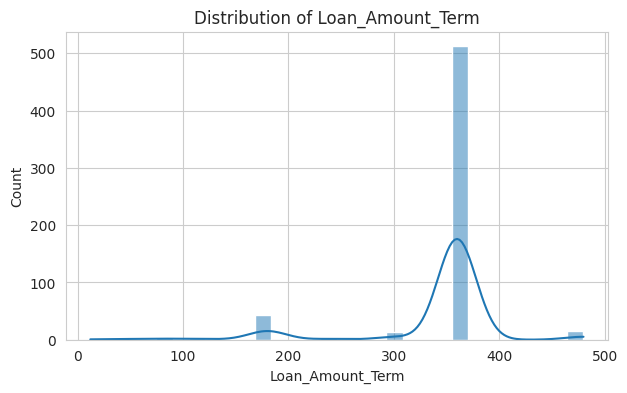

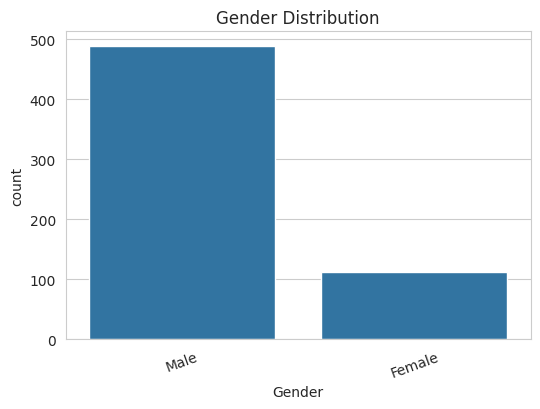

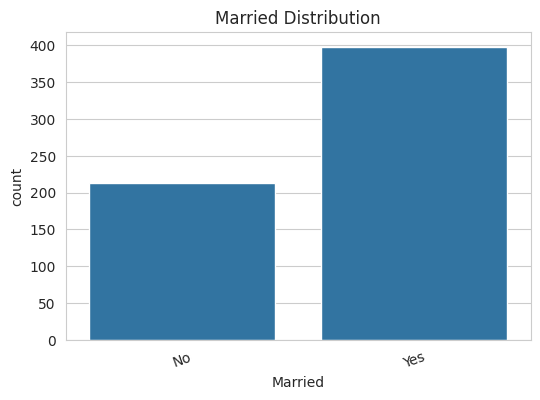

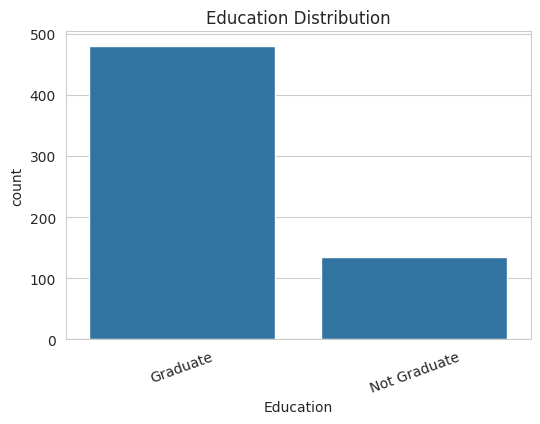

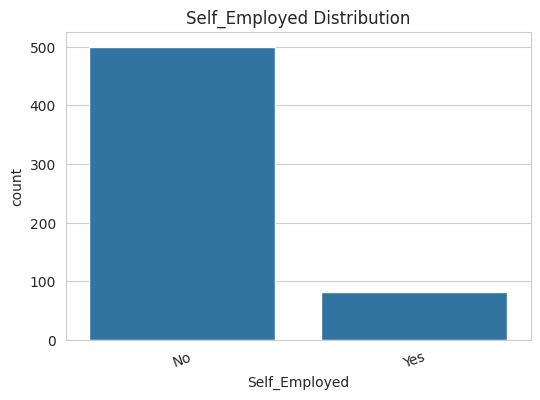

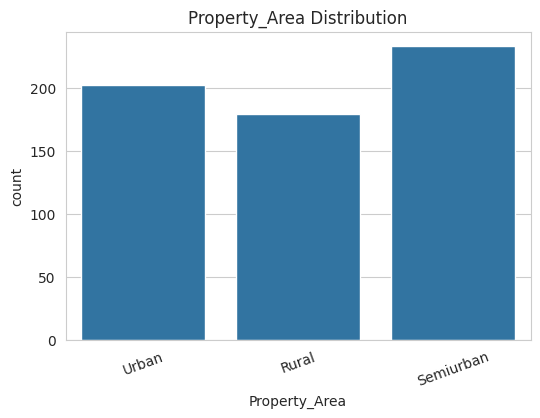

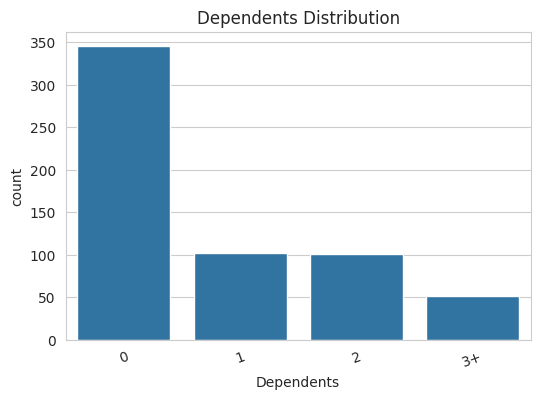

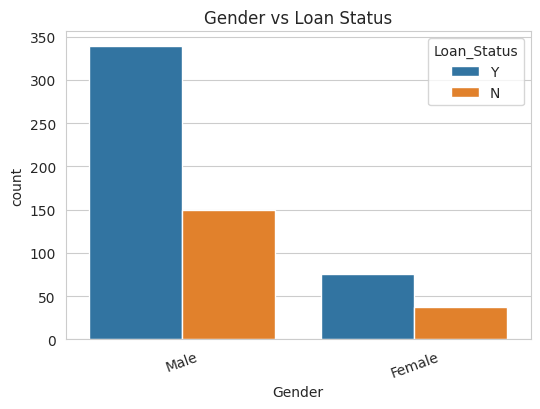

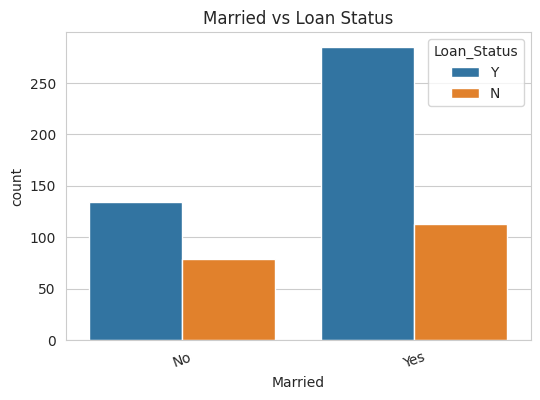

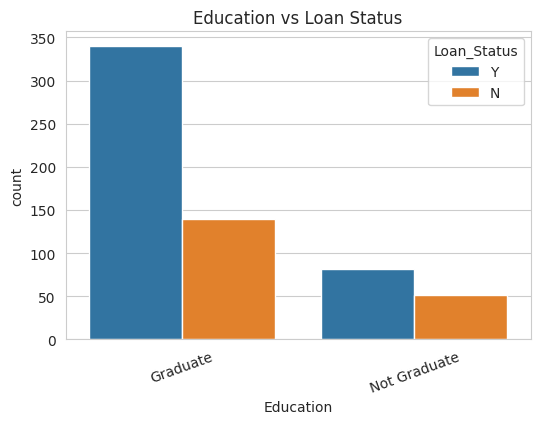

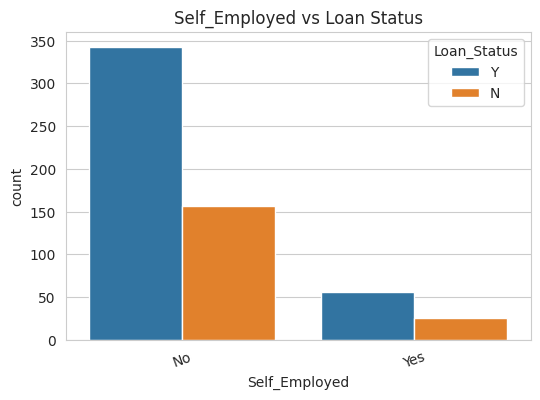

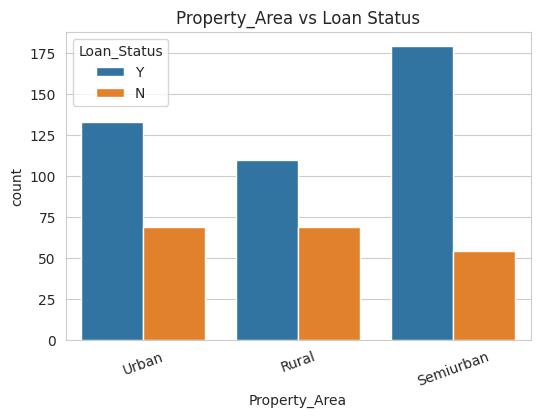

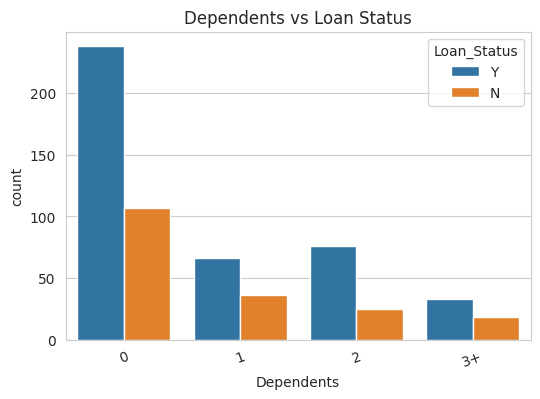

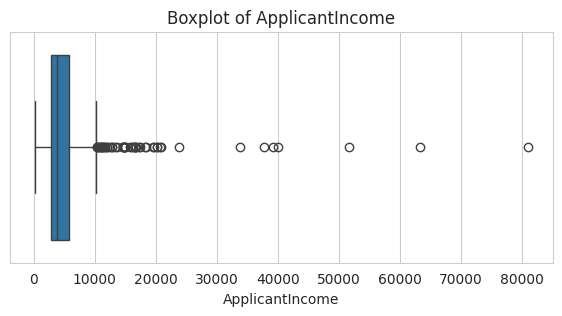

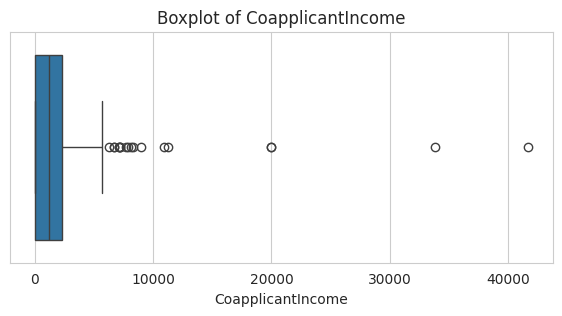

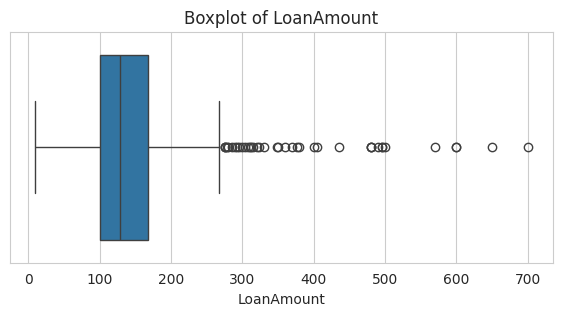

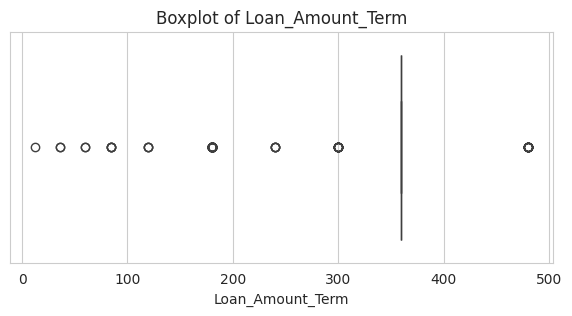

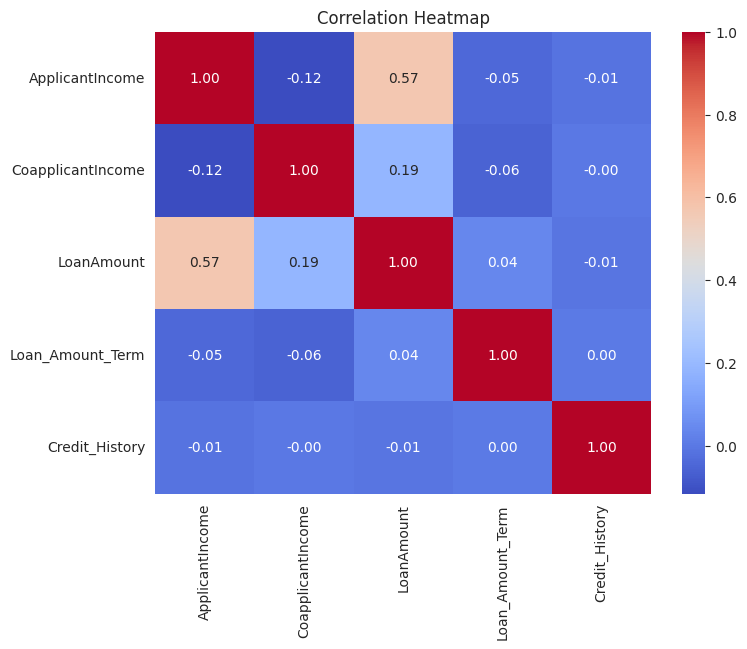

In [5]:
# Set plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

# 1. Target Variable Distribution

plt.figure(figsize=(6,4))
sns.countplot(x="Loan_Status", data=df)
plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

# 2. Numerical Feature Distributions

numerical_columns = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term"
]

for col in numerical_columns:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()

# 3. Categorical Feature Distribution

categorical_columns = [
    "Gender",
    "Married",
    "Education",
    "Self_Employed",
    "Property_Area",
    "Dependents"
]

for col in categorical_columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=20)
    plt.show()

# 4. Loan Status vs Categorical Features

for col in categorical_columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue="Loan_Status", data=df)
    plt.title(f"{col} vs Loan Status")
    plt.xticks(rotation=20)
    plt.show()


# 5. Boxplots (Outlier Detection)

for col in numerical_columns:
    plt.figure(figsize=(7,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

# 6. Correlation Heatmap


numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(8,6))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# 🛠️ Phase 3: Data Preprocessing

In this phase we prepare the data for machine learning by:

- Handling missing values
- Encoding categorical features
- Splitting features and target
- Creating a preprocessing pipeline

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Features & Target

X = df.drop(["Loan_ID", "Loan_Status"], axis=1)
y = df["Loan_Status"]

# Numerical & Categorical Columns

numerical_features = X.select_dtypes(include=["int64", "float64"]).columns

categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical Features :", list(numerical_features))
print("Categorical Features :", list(categorical_features))

# Preprocessing Pipelines

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples :", X_train.shape)
print("Testing Samples  :", X_test.shape)

print("\n✅ Phase 3 Completed Successfully!")

Numerical Features : ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
Categorical Features : ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']

Training Samples : (491, 11)
Testing Samples  : (123, 11)

✅ Phase 3 Completed Successfully!


# 🤖 Phase 4: Model Training

In this phase, we will:

- Train multiple machine learning models
- Evaluate them on the test dataset
- Compare their performance
- Select the best-performing model

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score

# Models

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

results = {}

print("TRAINING MODELS")

# Train Models

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results[name] = {
        "Accuracy": accuracy,
        "Pipeline": pipeline
    }

    print(f"{name:<22}: {accuracy:.4f}")

# Comparison Table

results_df = pd.DataFrame({
    "Model": results.keys(),
    "Accuracy": [results[m]["Accuracy"] for m in results]
})

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print("\nModel Comparison\n")
display(results_df)
print("Final Model Selected")

best_model_name = "Random Forest"
best_model = results["Random Forest"]["Pipeline"]

rf_accuracy = results["Random Forest"]["Accuracy"]

print(f"Model    : {best_model_name}")
print(f"Accuracy : {rf_accuracy:.4f}")


TRAINING MODELS
Logistic Regression   : 0.8618
Decision Tree         : 0.7561
Random Forest         : 0.8211
KNN                   : 0.8699
Naive Bayes           : 0.8455

Model Comparison



,Model,Accuracy
3,KNN,0.869919
0,Logistic Regression,0.861789
4,Naive Bayes,0.845528
2,Random Forest,0.821138
1,Decision Tree,0.756098


Final Model Selected
Model    : Random Forest
Accuracy : 0.8211


# 📈 Phase 5: Model Evaluation

In this phase, we evaluate the best-performing model using:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- Classification Report

BEST MODEL : Random Forest
Accuracy  : 0.8211
Precision : 0.8462
Recall    : 0.9059
F1 Score  : 0.8750

Classification Report

              precision    recall  f1-score   support

           N       0.75      0.63      0.69        38
           Y       0.85      0.91      0.88        85

    accuracy                           0.82       123
   macro avg       0.80      0.77      0.78       123
weighted avg       0.82      0.82      0.82       123



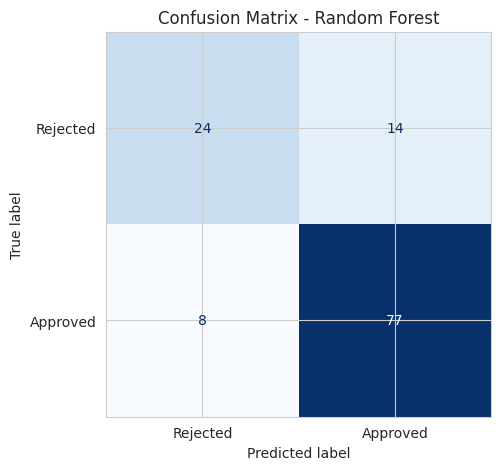


✅ Phase 5 Completed Successfully!


In [8]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# Predictions

y_pred = best_model.predict(X_test)

# Evaluation Metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label="Y")
recall = recall_score(y_test, y_pred, pos_label="Y")
f1 = f1_score(y_test, y_pred, pos_label="Y")

print("="*60)
print("BEST MODEL :", best_model_name)
print("="*60)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

# Classification Report

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix

cm = confusion_matrix(y_test, y_pred, labels=["N", "Y"])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Rejected", "Approved"]
)

fig, ax = plt.subplots(figsize=(6,5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

print("\n✅ Phase 5 Completed Successfully!")

# 💾 Phase 6: Save & Test the Model

In this phase, we will:

- Save the best trained model
- Load the saved model
- Predict using a sample loan application

This completes the Loan Approval Prediction System.

In [9]:
import joblib
# Save Model

joblib.dump(best_model, "loan_approval_model.pkl")

print("✅ Model Saved Successfully!")
print("Filename : loan_approval_model.pkl")

# Load Model

loaded_model = joblib.load("loan_approval_model.pkl")

print("\n✅ Model Loaded Successfully!")

# Sample Prediction

sample = pd.DataFrame({
    "Gender": ["Male"],
    "Married": ["Yes"],
    "Dependents": ["0"],
    "Education": ["Graduate"],
    "Self_Employed": ["No"],
    "ApplicantIncome": [5000],
    "CoapplicantIncome": [1500],
    "LoanAmount": [120],
    "Loan_Amount_Term": [360],
    "Credit_History": [1.0],
    "Property_Area": ["Urban"]
})

prediction = loaded_model.predict(sample)

print("\nSample Prediction")

if prediction[0] == "Y":
    print("✅ Loan Approved")
else:
    print("❌ Loan Rejected")

✅ Model Saved Successfully!
Filename : loan_approval_model.pkl

✅ Model Loaded Successfully!

Sample Prediction
✅ Loan Approved


# 🔮 Phase 7: Loan Approval Prediction

Enter a new applicant's details below and run the cell to predict whether the loan will be approved or rejected.

In [ ]:
import pandas as pd

print("ENTER APPLICANT DETAILS")

gender = input("Gender (Male/Female): ")
married = input("Married (Yes/No): ")
dependents = input("Dependents (0/1/2/3+): ")
education = input("Education (Graduate/Not Graduate): ")
self_employed = input("Self Employed (Yes/No): ")

applicant_income = float(input("Applicant Income: "))
coapplicant_income = float(input("Coapplicant Income: "))
loan_amount = float(input("Loan Amount: "))
loan_term = float(input("Loan Amount Term (e.g. 360): "))
credit_history = float(input("Credit History (1 or 0): "))

property_area = input("Property Area (Urban/Semiurban/Rural): ")

# Create DataFrame

sample = pd.DataFrame({
    "Gender": [gender],
    "Married": [married],
    "Dependents": [dependents],
    "Education": [education],
    "Self_Employed": [self_employed],
    "ApplicantIncome": [applicant_income],
    "CoapplicantIncome": [coapplicant_income],
    "LoanAmount": [loan_amount],
    "Loan_Amount_Term": [loan_term],
    "Credit_History": [credit_history],
    "Property_Area": [property_area]
})

# Prediction

prediction = best_model.predict(sample)

print("LOAN APPROVAL RESULT")

if prediction[0] == "Y":
    print("🎉 Loan Approved ✅")
else:
    print("❌ Loan Rejected")

# Probability (if available)

if hasattr(best_model, "predict_proba"):
    probability = best_model.predict_proba(sample)

    print(f"\nApproval Probability : {probability[0][1]*100:.2f}%")

ENTER APPLICANT DETAILS
